In [1]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [3]:
iris_df = pd.read_csv(io.BytesIO(uploaded["Iris.csv"]))
display(iris_df)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
iris_df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
X = iris_df.drop(["Id", "Species"], axis = 1)
y = iris_df["Species"]

In [6]:
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 3)

In [8]:
from sklearn.tree import DecisionTreeClassifier
clf_tree = DecisionTreeClassifier(criterion = 'entropy')

In [9]:
clf_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [10]:
# Accuracy on Test data
clf_tree.score(X_test, y_test)

0.9777777777777777

In [11]:
# Accuracy on Training data
clf_tree.score(X_train, y_train)

1.0

In [12]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
y_hat = clf_tree.predict(X_test)

In [13]:
confusion_matrix(y_test, y_hat)

array([[17,  0,  0],
       [ 0, 13,  1],
       [ 0,  0, 14]])

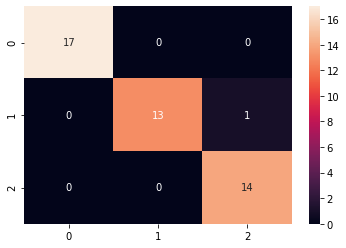

In [14]:
sns.heatmap(confusion_matrix(y_test, y_hat), annot = True, fmt='0.0f')

In [15]:
print(classification_report(y_test, y_hat))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        17
Iris-versicolor       1.00      0.93      0.96        14
 Iris-virginica       0.93      1.00      0.97        14

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



In [16]:
# Plotting Decision Tree
from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

/usr/local/lib/python3.7/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)


In [17]:
dot_data = StringIO()
export_graphviz(clf_tree, out_file= dot_data, feature_names= list(X.columns), filled = True, rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

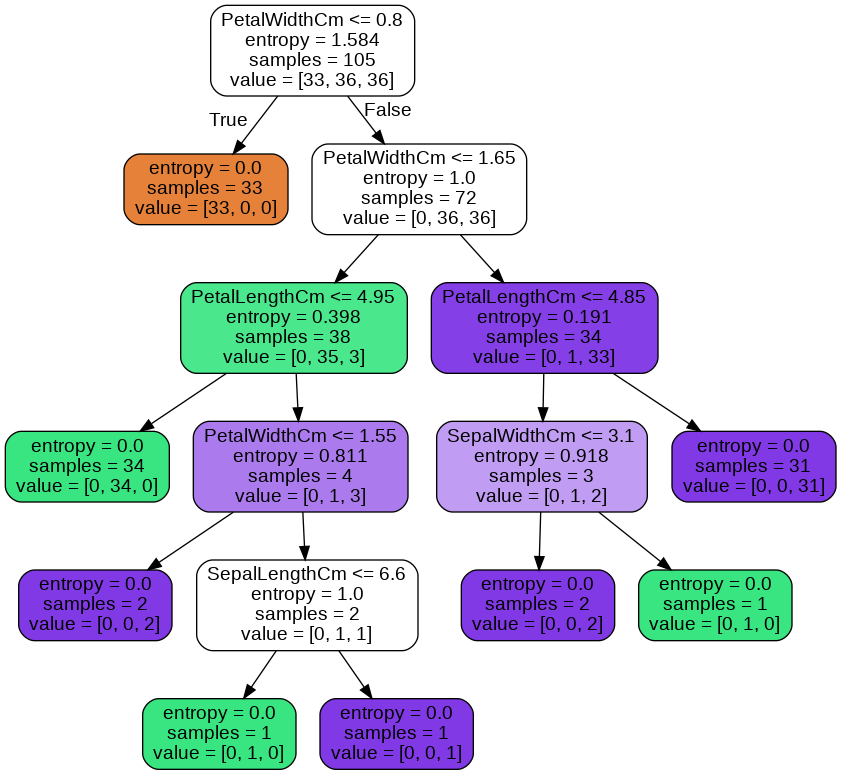

In [18]:
Image(graph.create_png())

In [19]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

In [20]:
clf_rf = RandomForestClassifier(bootstrap = True, max_depth = 10, n_estimators = 150, random_state = 0, criterion = 'entropy')
clf_rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=10, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=150,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0,
                       warm_start=False)

In [21]:
clf_rf.score(X_test, y_test)

0.9555555555555556

In [22]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
predictions = clf_rf.predict(X_test)

In [23]:
confusion_matrix(y_test, predictions)

array([[17,  0,  0],
       [ 0, 13,  1],
       [ 0,  1, 13]])

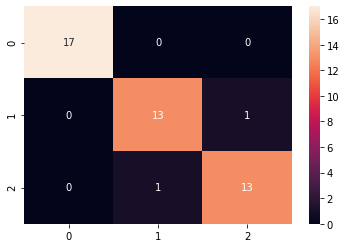

In [24]:
sns.heatmap(confusion_matrix(y_test, predictions), annot = True, fmt='0.0f')